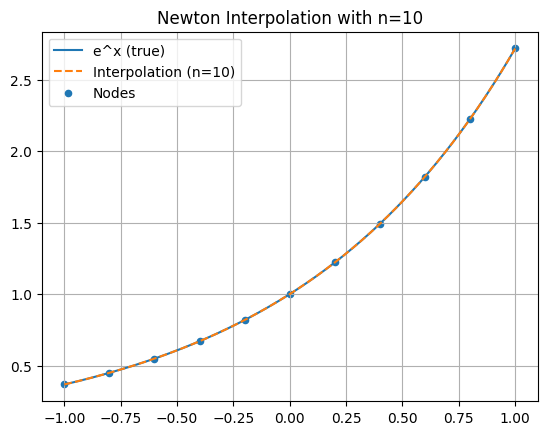

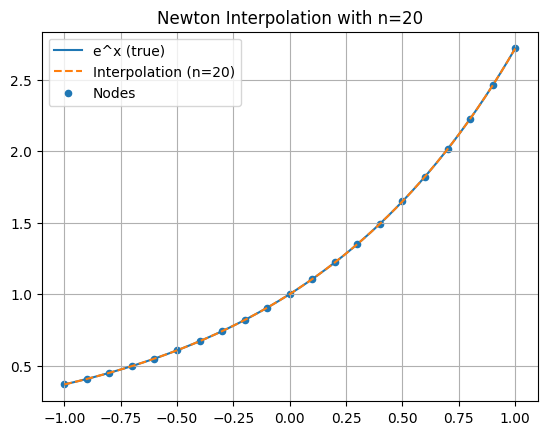

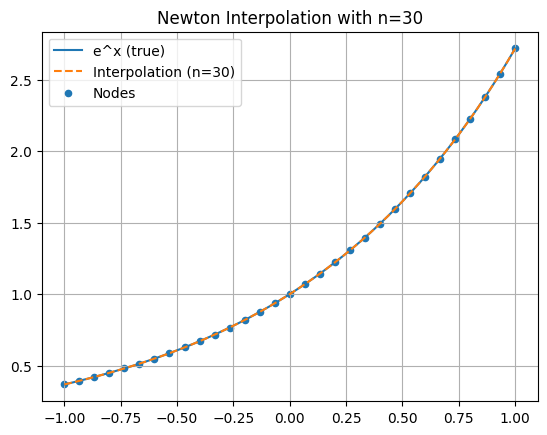

In [1]:
#UBUNG 1

import numpy as np
import matplotlib.pyplot as plt


def divided_differences(x, y):
    n = len(x)
    coef = np.copy(y).astype(float)

    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1]) / (x[j:n] - x[0:n-j])

    return coef


def newton_poly(coef, x_data, x):
    n = len(coef)
    p = coef[-1]

    for k in range(n-2, -1, -1):
        p = p * (x - x_data[k]) + coef[k]

    return p



def f(x):
    return np.exp(x)



def run_case(n):
    x_data = np.linspace(-1, 1, n + 1)
    y_data = f(x_data)

    coef = divided_differences(x_data, y_data)

    x_plot = np.linspace(-1, 1, 500)
    y_true = f(x_plot)
    y_interp = newton_poly(coef, x_data, x_plot)


    plt.figure()
    plt.plot(x_plot, y_true, label="e^x (true)")
    plt.plot(x_plot, y_interp, '--', label=f"Interpolation (n={n})")
    plt.scatter(x_data, y_data, s=20, label="Nodes")

    plt.title(f"Newton Interpolation with n={n}")
    plt.legend()
    plt.grid()

    plt.show() 



for n in [10, 20, 30]:
    run_case(n)

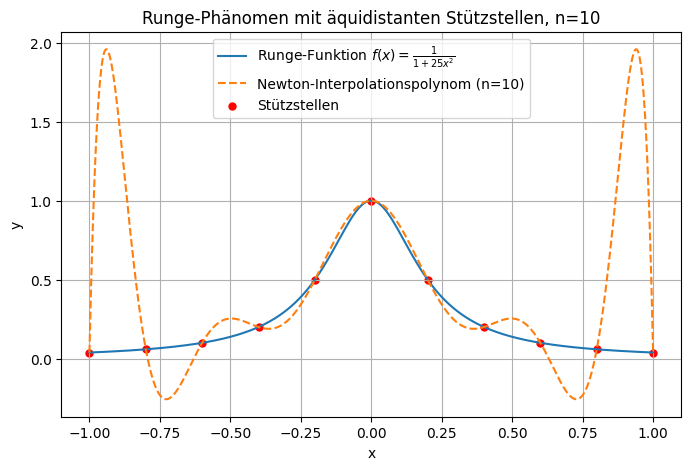

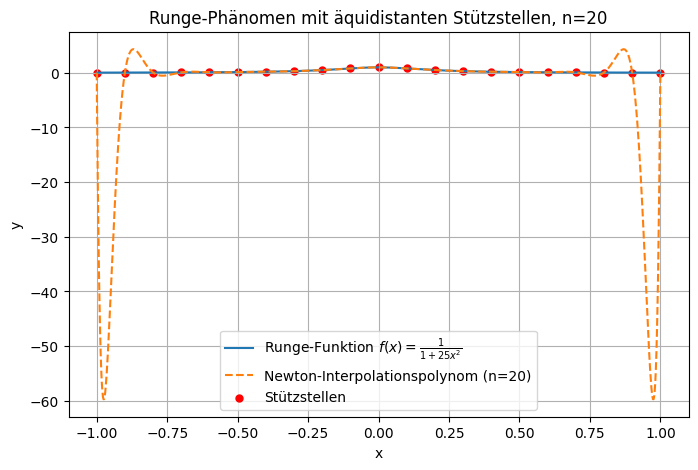

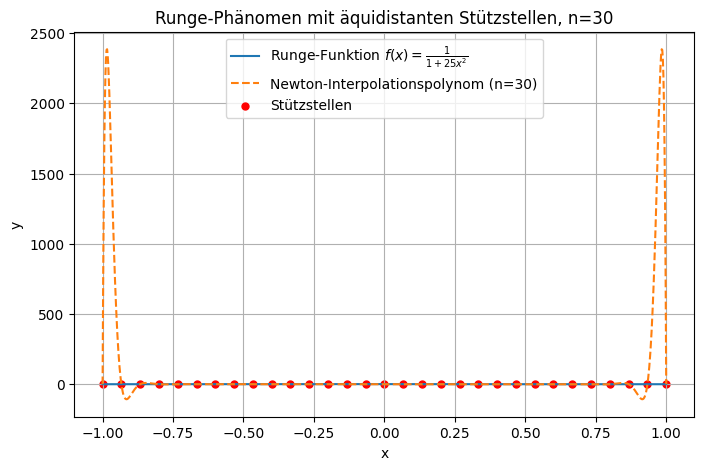

In [2]:
#UBUNG 2

import numpy as np
import matplotlib.pyplot as plt


def divided_differences(x, y):
    length = len(x)
    coef = np.copy(y).astype(float)

    for j in range(1, length):
        coef[j:length] = (coef[j:length] - coef[j-1:length-1]) / (x[j:length] - x[0:length-j])

    return coef


def newton_poly(coef, x_data, x):
    length = len(coef)
    p = coef[-1]

    for k in range(length - 2, -1, -1):
        p = p * (x - x_data[k]) + coef[k]

    return p


def f(x):
    return 1 / (1 + 25 * x**2)


def run_case(n):
    # n+1 equidistant nodes in [-1, 1]
    x_data = np.linspace(-1, 1, n + 1)
    y_data = f(x_data)

    # Newton coefficients through divided differences
    coef = divided_differences(x_data, y_data)

    x_plot = np.linspace(-1, 1, 1000)
    y_true = f(x_plot)
    y_interp = newton_poly(coef, x_data, x_plot)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(x_plot, y_true, label=r"Runge-Funktion $f(x)=\frac{1}{1+25x^2}$")
    plt.plot(x_plot, y_interp, '--', label=f"Newton-Interpolationspolynom (n={n})")
    plt.scatter(x_data, y_data, color='red', s=25, label="Stützstellen")

    plt.title(f"Runge-Phänomen mit äquidistanten Stützstellen, n={n}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()


for n in [10, 20, 30]:
    run_case(n)

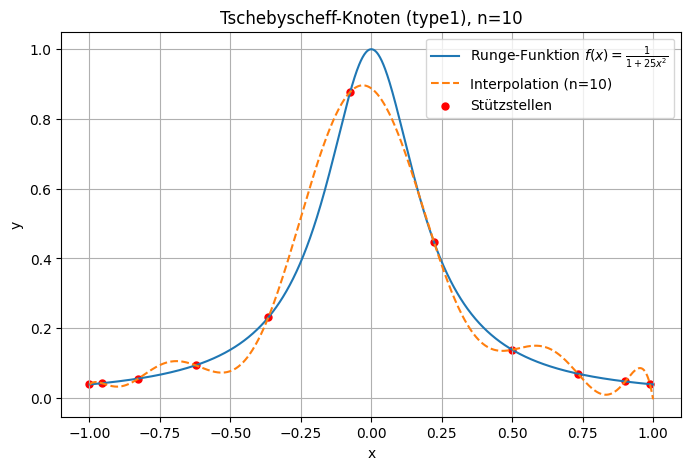

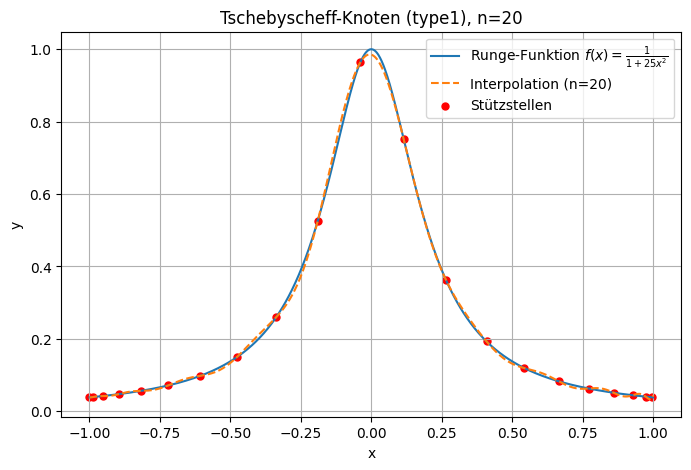

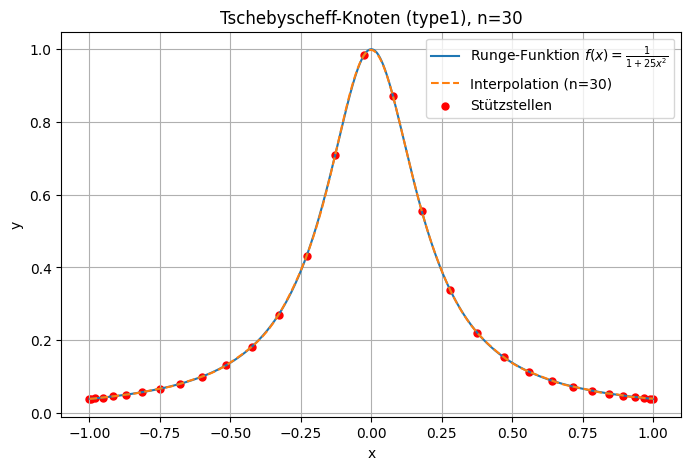

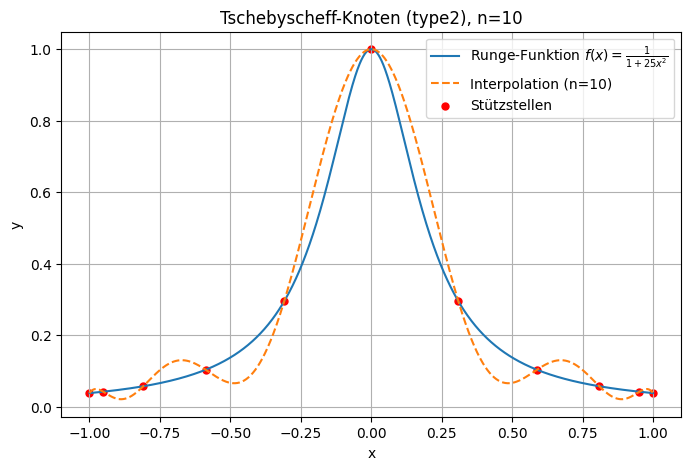

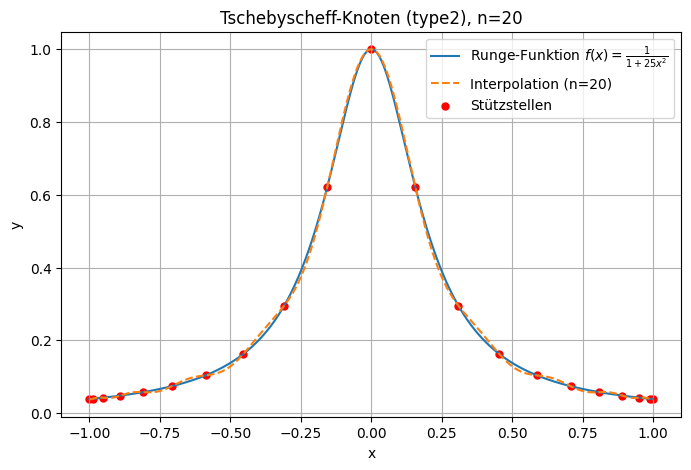

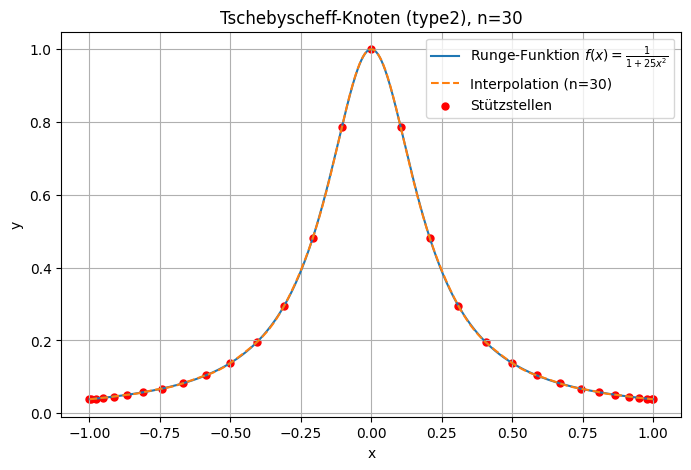

In [3]:
#UBUNG 3

import numpy as np
import matplotlib.pyplot as plt

def divided_differences(x, y):
    n = len(x)
    coef = np.copy(y).astype(float)

    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1]) / (x[j:n] - x[0:n-j])

    return coef


def newton_poly(coef, x_data, x):
    n = len(coef)
    p = coef[-1]

    for k in range(n-2, -1, -1):
        p = p * (x - x_data[k]) + coef[k]

    return p


def f(x):
    return 1 / (1 + 25 * x**2)


def chebyshev_nodes_type1(n):
    i = np.arange(0, n+1)
    return np.cos((2*i + 1) * np.pi / (2*n + 1))


def chebyshev_nodes_type2(n):
    i = np.arange(0, n+1)
    return np.cos(i * np.pi / n)


def run_case(n, node_type="type1"):

    if node_type == "type1":
        x_data = chebyshev_nodes_type1(n)
    elif node_type == "type2":
        x_data = chebyshev_nodes_type2(n)
    else:
        raise ValueError("Unknown node type")

    x_data = np.sort(x_data)

    y_data = f(x_data)

    coef = divided_differences(x_data, y_data)

    x_plot = np.linspace(-1, 1, 1000)
    y_true = f(x_plot)
    y_interp = newton_poly(coef, x_data, x_plot)

    plt.figure(figsize=(8, 5))
    plt.plot(x_plot, y_true, label=r"Runge-Funktion $f(x)=\frac{1}{1+25x^2}$")
    plt.plot(x_plot, y_interp, '--', label=f"Interpolation (n={n})")
    plt.scatter(x_data, y_data, color='red', s=25, label="Stützstellen")

    plt.title(f"Tschebyscheff-Knoten ({node_type}), n={n}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

for n in [10, 20, 30]:
    run_case(n, "type1")

for n in [10, 20, 30]:
    run_case(n, "type2")

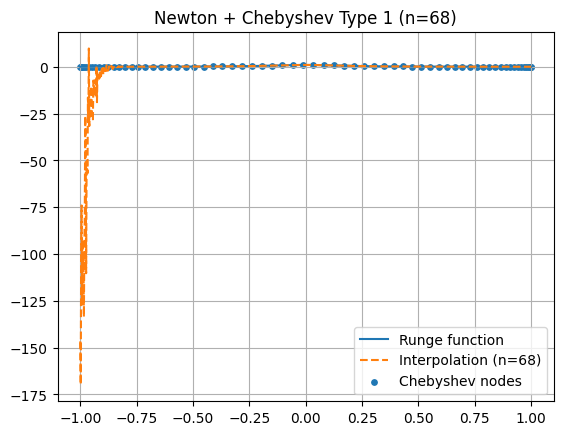

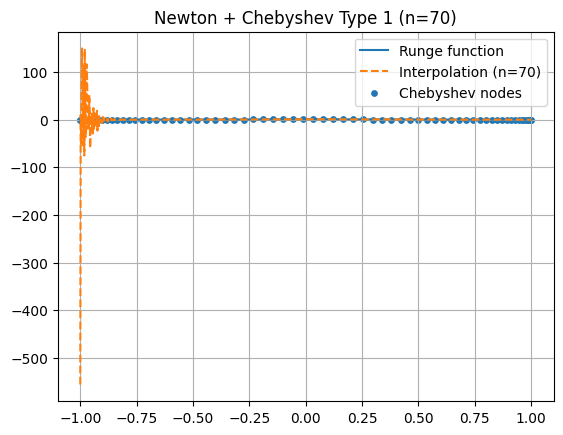

In [4]:
#Übung 4
import numpy as np
import matplotlib.pyplot as plt


def divided_differences(x, y):
    n = len(x) #p
    coef = np.copy(y).astype(float)

    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1]) / (x[j:n] - x[0:n-j])

    return coef


def newton_poly(coef, x_data, x):
    n = len(coef)
    p = coef[-1]

    for k in range(n-2, -1, -1):
        p = p * (x - x_data[k]) + coef[k]

    return p
 

def f(x):
    return 1 / (1 + 25 * x**2)


def chebyshev_nodes_type1(n):
    i = np.arange(0, n+1)
    return np.cos((2*i + 1) * np.pi / (2*n + 1))


def run_case(n):
    x_data = chebyshev_nodes_type1(n)
    y_data = f(x_data)

    coef = divided_differences(x_data, y_data)

    x_plot = np.linspace(-1, 1, 1000)
    y_true = f(x_plot)
    y_interp = newton_poly(coef, x_data, x_plot)

    plt.figure()
    plt.plot(x_plot, y_true, label="Runge function")
    plt.plot(x_plot, y_interp, '--', label=f"Interpolation (n={n})")
    plt.scatter(x_data, y_data, s=15, label="Chebyshev nodes")

    plt.title(f"Newton + Chebyshev Type 1 (n={n})")
    plt.legend()
    plt.grid()

    plt.show()


for n in [68, 70]:
    run_case(n)